# **Data Mining UAS: NETFLIX DATASET**

**Langkah 1: Upload Data**

In [2]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Netflix Datasets Evaluation MS Excel.csv")
df.head()

Saving Netflix Datasets Evaluation MS Excel.csv to Netflix Datasets Evaluation MS Excel.csv


,show_id,type,title,director,cast,country,date_added,date_added.1,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",25-09-2021,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",24-09-2021,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",24-09-2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",24-09-2021,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",24-09-2021,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Langkah 2: Explorasi Data**

In [ ]:
df.info()
print("\nMissing values:\n, df.isnull().sum")
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   date_added.1  8797 non-null   object
 8   release_year  8807 non-null   int64 
 9   rating        8803 non-null   object
 10  duration      8804 non-null   object
 11  listed_in     8807 non-null   object
 12  description   8807 non-null   object
dtypes: int64(1), object(12)
memory usage: 894.6+ KB

Missing values:
, df.isnull().sum


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'date_added.1', 'release_year', 'rating', 'duration', 'listed_in',
       'description'],
      dtype='object')

**Langkah 3: Visualisasi Keseluruhan Data**

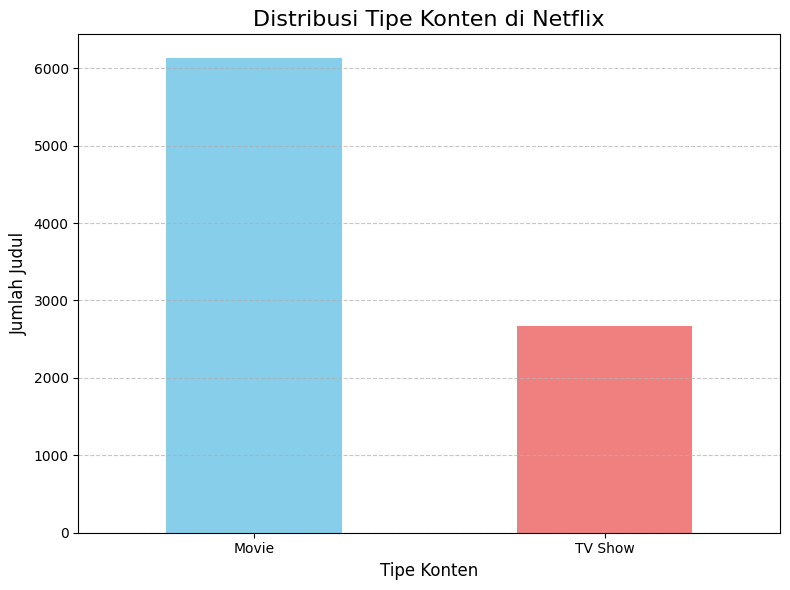

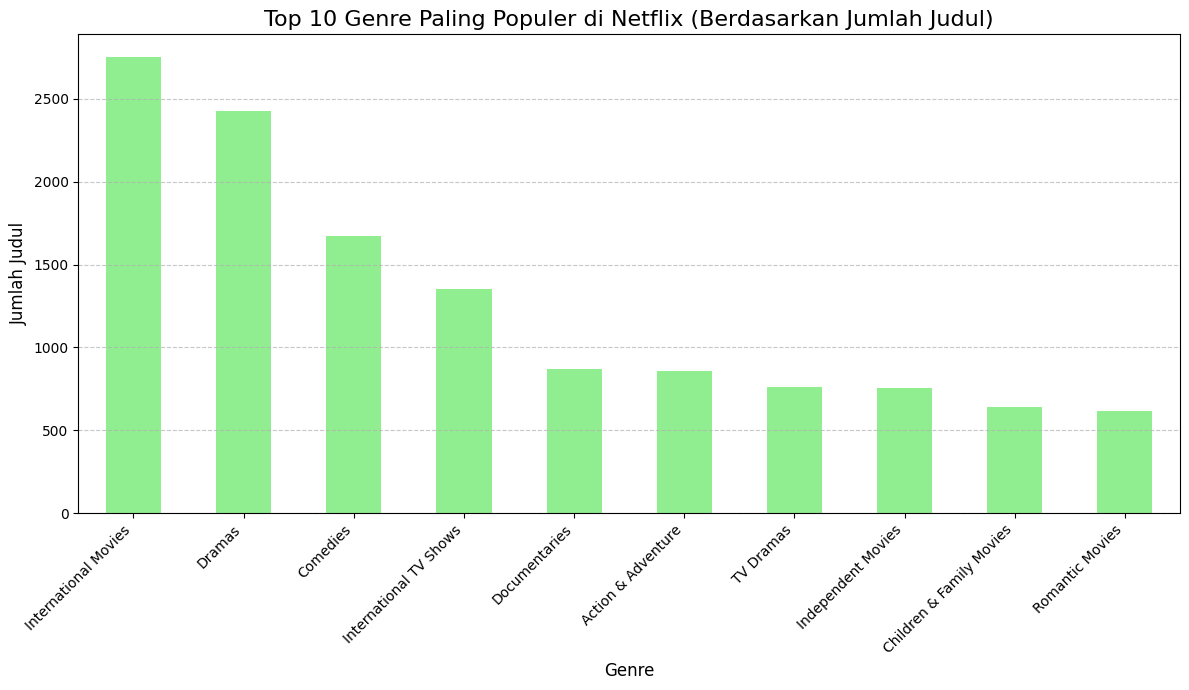

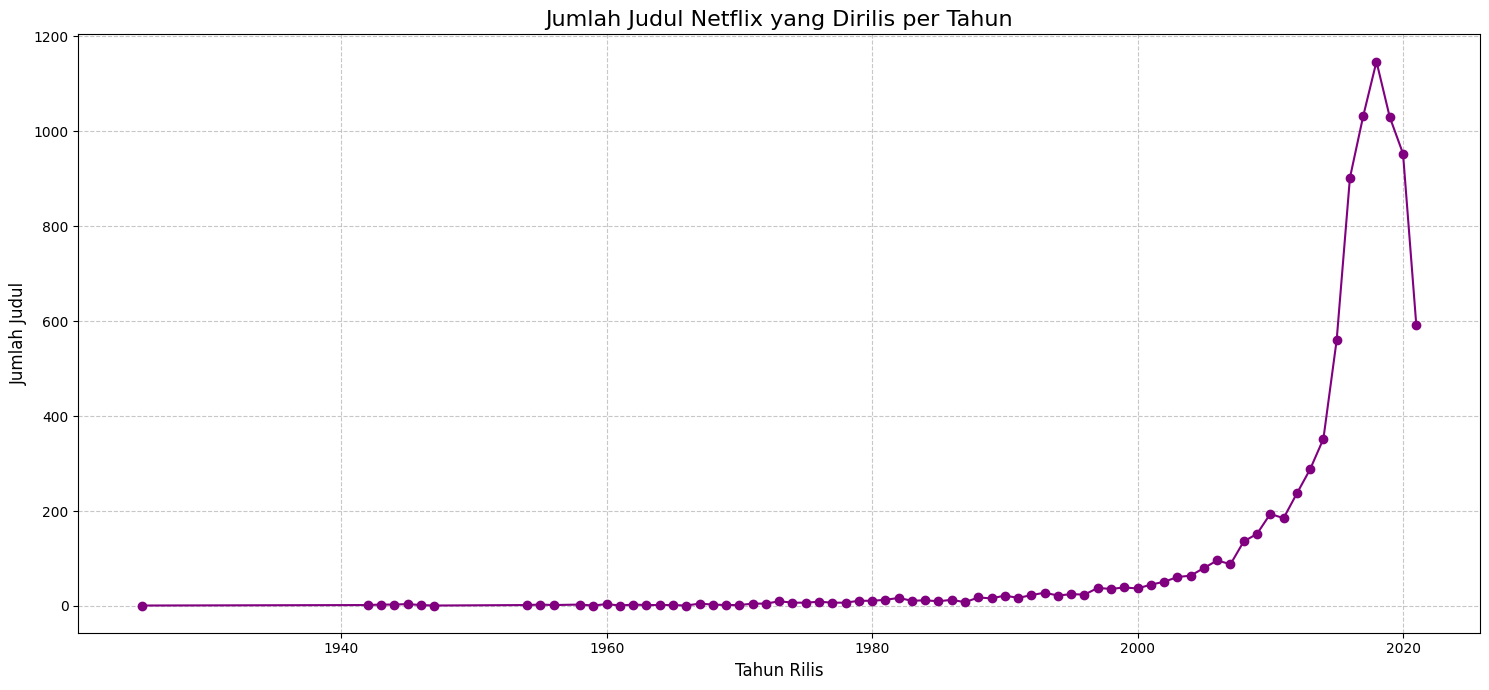

<ipython-input-21-276619569>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='viridis')


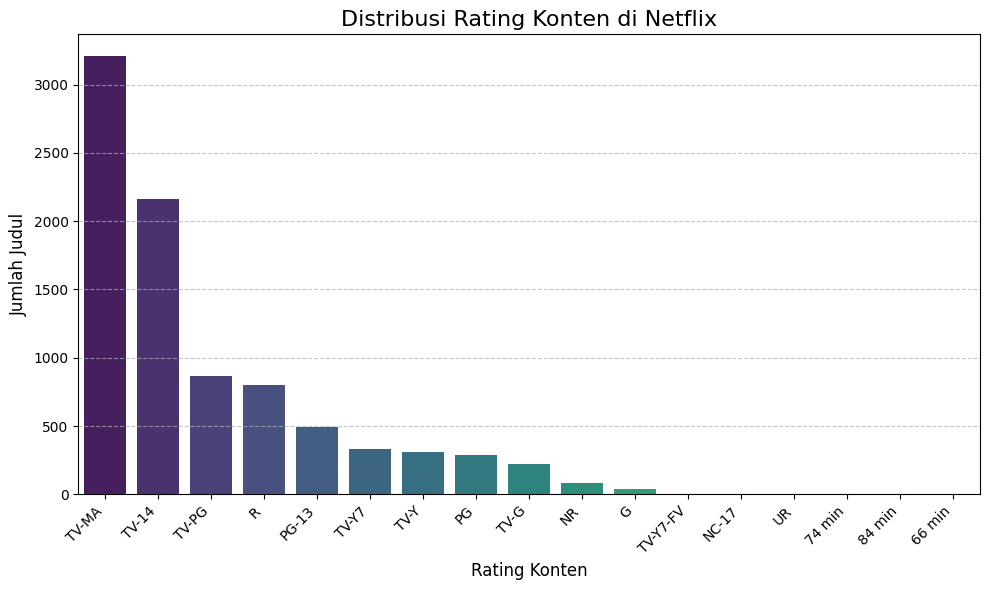

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

if df is not None:
    # --- Visualisasi 1: Distribusi Tipe Konten (Film vs. Acara TV) ---
    # Menggunakan kolom 'type'
    plt.figure(figsize=(8, 6))
    df['type'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
    plt.title('Distribusi Tipe Konten di Netflix', fontsize=16)
    plt.xlabel('Tipe Konten', fontsize=12)
    plt.ylabel('Jumlah Judul', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Visualisasi 2: Popularitas Genre (Top 10 Genre) ---
    # Menggunakan kolom 'listed_in' dan memisahkannya jika ada multiple genre
    # Pastikan 'listed_in' tidak memiliki nilai NaN sebelum split
    all_genres = df['listed_in'].dropna().str.split(', ').explode()

    plt.figure(figsize=(12, 7))
    all_genres.value_counts().head(10).plot(kind='bar', color='lightgreen')
    plt.title('Top 10 Genre Paling Populer di Netflix (Berdasarkan Jumlah Judul)', fontsize=16)
    plt.xlabel('Genre', fontsize=12)
    plt.ylabel('Jumlah Judul', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Visualisasi 3: Pola Rilis Temporal (Jumlah Judul per Tahun Rilis) ---
    # Menggunakan kolom 'release_year'
    plt.figure(figsize=(15, 7))
    df['release_year'].value_counts().sort_index().plot(kind='line', marker='o', color='purple')
    plt.title('Jumlah Judul Netflix yang Dirilis per Tahun', fontsize=16)
    plt.xlabel('Tahun Rilis', fontsize=12)
    plt.ylabel('Jumlah Judul', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Visualisasi 4: Distribusi Rating Konten ---
    # Menggunakan kolom 'rating'
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='viridis')
    plt.title('Distribusi Rating Konten di Netflix', fontsize=16)
    plt.xlabel('Rating Konten', fontsize=12)
    plt.ylabel('Jumlah Judul', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

**Langkah 4: FILTER DATA**

**Bagian 1: Melakukan filter untuk hanya menampilkan data hollywood saja**

In [9]:
import pandas as pd

# (Asumsi df sudah dimuat dari Bagian 1)
# Jika Anda menjalankan bagian ini secara terpisah, pastikan df sudah ada.
try:
    df = pd.read_csv("Netflix Datasets Evaluation MS Excel.csv")
except FileNotFoundError:
    print("ERROR: File 'Netflix Datasets Evaluation MS Excel.csv' tidak ditemukan. Tidak dapat memfilter data Hollywood.")
    exit()

if df is not None:
    # --- Bagian 2: Pra-pemrosesan & Filter Data untuk Film/Konten Hollywood ---
    print("\n--- Memfilter Data Hollywood ---")

    # Definisikan dataframe Hollywood terlebih dahulu
    # Pastikan kolom 'country' ada dan tidak kosong sebelum operasi string
    df_filtered_for_hollywood = df.dropna(subset=['country']).copy() # Use .copy() to avoid SettingWithCopyWarning

    # Ubah kolom 'country' menjadi string untuk memastikan operasi str.contains() berjalan lancar
    df_filtered_for_hollywood['country'] = df_filtered_for_hollywood['country'].astype(str)

    # Filter film atau acara TV yang diproduksi di "United States" (dianggap Hollywood)
    # case=False: case-insensitive
    # na=False: treat NaN values as False (will not be included)
    hollywood_content_df = df_filtered_for_hollywood[df_filtered_for_hollywood['country'].str.contains('United States', case=False, na=False)]

    print(f"Jumlah judul konten Hollywood (film & TV Show) yang teridentifikasi: {len(hollywood_content_df)}")
    print("5 baris pertama konten Hollywood:")
    print(hollywood_content_df.head())


--- Memfilter Data Hollywood ---
Jumlah judul konten Hollywood (film & TV Show) yang teridentifikasi: 3690
5 baris pertama konten Hollywood:
   show_id     type                 title         director  \
0       s1    Movie  Dick Johnson Is Dead  Kirsten Johnson   
7       s8    Movie               Sankofa     Haile Gerima   
9      s10    Movie          The Starling   Theodore Melfi   
15     s16  TV Show     Dear White People              NaN   
27     s28    Movie             Grown Ups     Dennis Dugan   

                                                 cast  \
0                                                 NaN   
7   Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
9   Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...   
15  Logan Browning, Brandon P. Bell, DeRon Horton,...   
27  Adam Sandler, Kevin James, Chris Rock, David S...   

                                              country          date_added  \
0                                       United States  September 

**Bagian 2: Visualisasi data hanya menampilkan data hollywood saja**


--- Memulai Visualisasi Data Hollywood ---


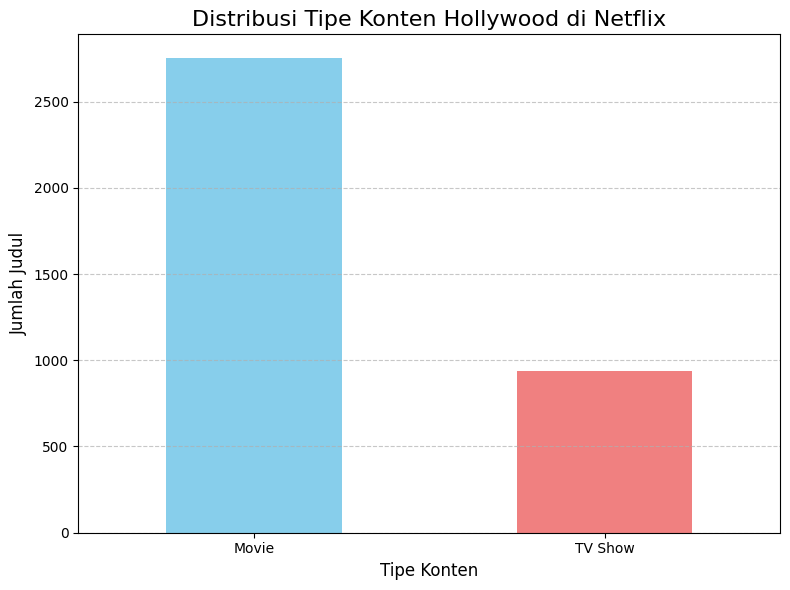

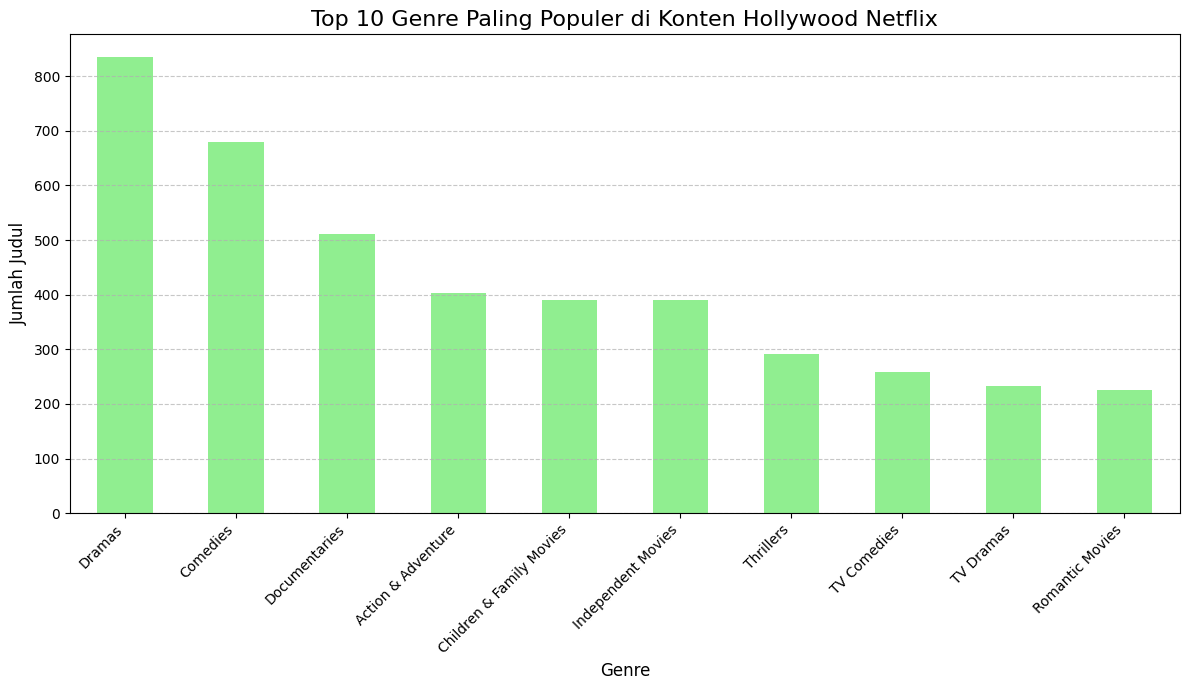

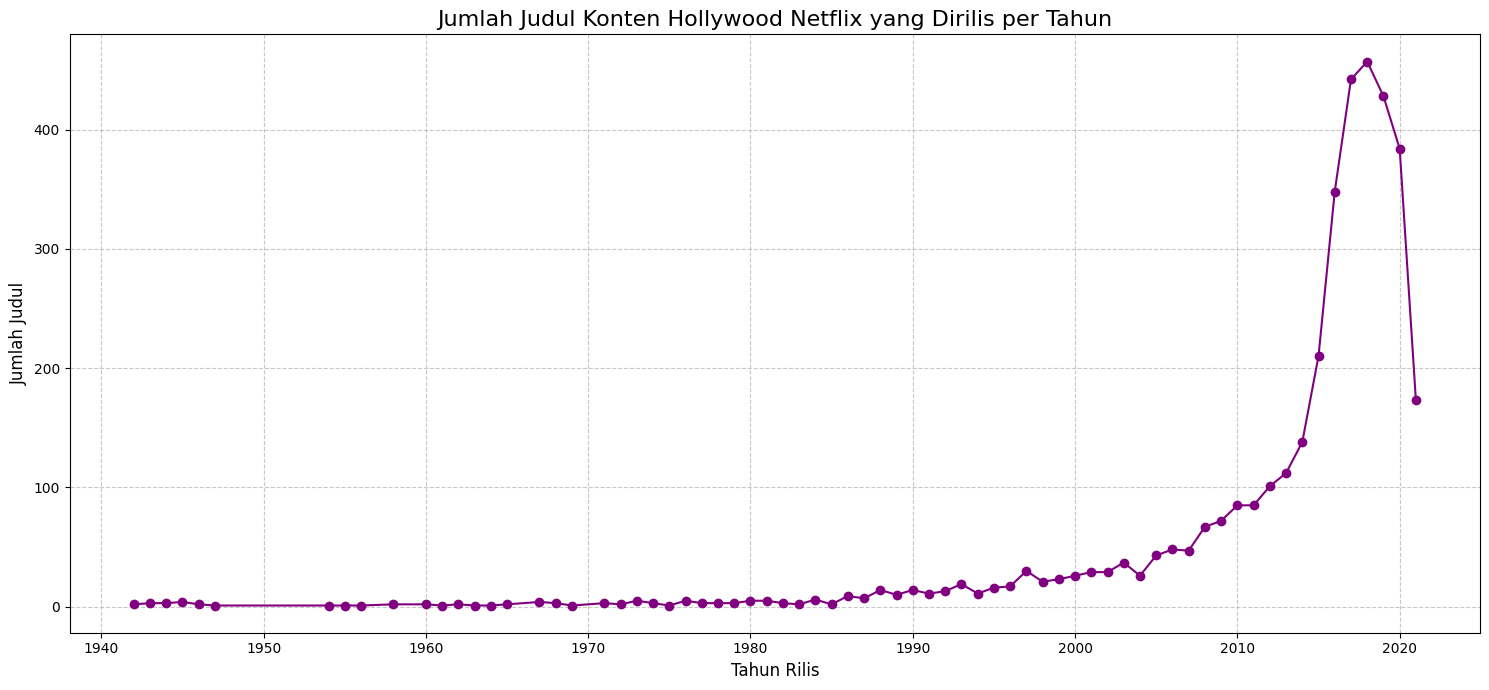

/tmp/ipython-input-13-672359797.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hollywood_content_df, x='rating', order=hollywood_content_df['rating'].value_counts().index, palette='viridis')


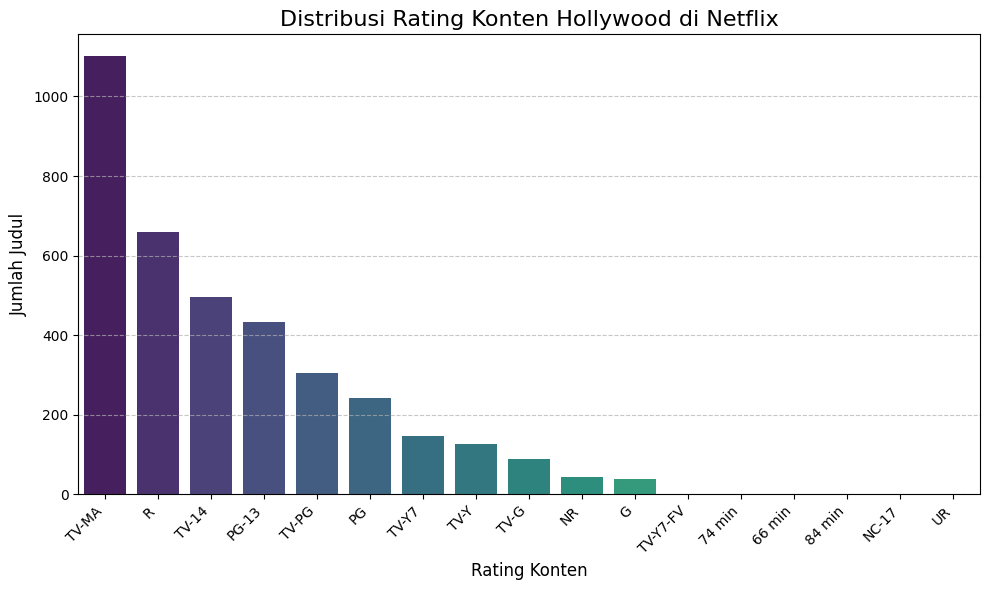


--- Visualisasi Data Hollywood Selesai ---


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (Asumsi hollywood_content_df sudah dibuat dari Bagian Data Hollywood Saja)
# Jika Anda menjalankan bagian ini secara terpisah, pastikan df dan hollywood_content_df sudah ada.
try:
    df = pd.read_csv("Netflix Datasets Evaluation MS Excel.csv")
    df_filtered_for_hollywood = df.dropna(subset=['country']).copy()
    df_filtered_for_hollywood['country'] = df_filtered_for_hollywood['country'].astype(str)
    hollywood_content_df = df_filtered_for_hollywood[df_filtered_for_hollywood['country'].str.contains('United States', case=False, na=False)]
except FileNotFoundError:
    print("ERROR: File 'Netflix Datasets Evaluation MS Excel.csv' tidak ditemukan. Tidak dapat membuat visualisasi Hollywood.")
    exit()

if df is not None:
    print("\n--- Memulai Visualisasi Data Hollywood ---")

    if not hollywood_content_df.empty: # Make sure there is data after filtering
        # --- Visualisasi 1: Distribusi Tipe Konten Hollywood (Film vs. Acara TV) ---
        plt.figure(figsize=(8, 6))
        hollywood_content_df['type'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
        plt.title('Distribusi Tipe Konten Hollywood di Netflix', fontsize=16)
        plt.xlabel('Tipe Konten', fontsize=12)
        plt.ylabel('Jumlah Judul', fontsize=12)
        plt.xticks(rotation=0)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # --- Visualisasi 2: Popularitas Genre Hollywood (Top 10 Genre) ---
        # Using 'listed_in' column and splitting if there are multiple genres
        hollywood_genres = hollywood_content_df['listed_in'].dropna().str.split(', ').explode()

        if not hollywood_genres.empty: # Make sure there are genres after explode
            plt.figure(figsize=(12, 7))
            hollywood_genres.value_counts().head(10).plot(kind='bar', color='lightgreen')
            plt.title('Top 10 Genre Paling Populer di Konten Hollywood Netflix', fontsize=16)
            plt.xlabel('Genre', fontsize=12)
            plt.ylabel('Jumlah Judul', fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
        else:
            print("Tidak ada genre yang valid ditemukan untuk konten Hollywood setelah pembersihan.")

        # --- Visualisasi 3: Pola Rilis Temporal Konten Hollywood (Jumlah Judul per Tahun Rilis) ---
        plt.figure(figsize=(15, 7))
        hollywood_content_df['release_year'].value_counts().sort_index().plot(kind='line', marker='o', color='purple')
        plt.title('Jumlah Judul Konten Hollywood Netflix yang Dirilis per Tahun', fontsize=16)
        plt.xlabel('Tahun Rilis', fontsize=12)
        plt.ylabel('Jumlah Judul', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # --- Visualisasi 4: Distribusi Rating Konten Hollywood ---
        plt.figure(figsize=(10, 6))
        sns.countplot(data=hollywood_content_df, x='rating', order=hollywood_content_df['rating'].value_counts().index, palette='viridis')
        plt.title('Distribusi Rating Konten Hollywood di Netflix', fontsize=16)
        plt.xlabel('Rating Konten', fontsize=12)
        plt.ylabel('Jumlah Judul', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("Tidak ada konten Hollywood yang ditemukan dalam dataset setelah filter. Tidak dapat membuat visualisasi.")

    print("\n--- Visualisasi Data Hollywood Selesai ---")

**Langkah 5: ALGORITMA DECISION TREE**

**Bagian 1: Prediksi Konten Hollywood Tahun 2026 dengan Algoritma Decision Tree**

In [21]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt # Diperlukan untuk avg_movie_duration/avg_tvshow_duration

# --- Fungsi untuk Memuat dan Memfilter Data Hollywood ---
def load_and_filter_hollywood_data(file_path="Netflix Datasets Evaluation MS Excel.csv"):
    df = None
    try:
        df = pd.read_csv(file_path)
        print("Data berhasil dimuat.")
    except FileNotFoundError:
        print(f"ERROR: File '{file_path}' tidak ditemukan.")
        print("Pastikan nama file dan path sudah benar, dan file sudah diunggah.")
        return None

    if df is not None:
        print("\n--- Memfilter Data Hollywood ---")
        df_filtered_for_hollywood = df.dropna(subset=['country']).copy()
        df_filtered_for_hollywood['country'] = df_filtered_for_hollywood['country'].astype(str)
        hollywood_content_df = df_filtered_for_hollywood[df_filtered_for_hollywood['country'].str.contains('United States', case=False, na=False)]

        if hollywood_content_df.empty:
            print("Tidak ada konten Hollywood yang ditemukan.")
            return None
        print(f"Jumlah judul konten Hollywood: {len(hollywood_content_df)}")
        return hollywood_content_df
    return None

# --- Bagian 1: Muat dan Filter Data Hollywood ---
hollywood_df = load_and_filter_hollywood_data()

if hollywood_df is None:
    print("Tidak dapat melanjutkan karena data Hollywood tidak berhasil dimuat.")
    exit()

# --- Bagian 2: Pra-pemrosesan Data untuk Decision Tree ---
print("\n--- Pra-pemrosesan Data untuk Decision Tree ---")

hollywood_df['duration_numeric'] = hollywood_df['duration'].str.extract('(\d+)').astype(float)
hollywood_df['duration_numeric'] = hollywood_df['duration_numeric'].fillna(hollywood_df['duration_numeric'].median())

features = ['release_year', 'rating', 'duration_numeric']
target = 'type'

hollywood_content_df_cleaned = hollywood_df[features + [target]].dropna()

if hollywood_content_df_cleaned.empty:
    print("DataFrame Hollywood kosong setelah pembersihan NaN pada fitur yang dipilih. Tidak dapat melatih model.")
    exit()

le_rating = LabelEncoder()
hollywood_content_df_cleaned['rating_encoded'] = le_rating.fit_transform(hollywood_content_df_cleaned['rating'])
features_for_model = ['release_year', 'rating_encoded', 'duration_numeric']

X = hollywood_content_df_cleaned[features_for_model]
y = hollywood_content_df_cleaned[target]

le_type = LabelEncoder()
y_encoded = le_type.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Ukuran training set: {len(X_train)} | Ukuran testing set: {len(X_test)}")

# --- Bagian 3: Pelatihan Model Decision Tree ---
print("\n--- Melatih Model Decision Tree ---")
model_dt = DecisionTreeClassifier(random_state=42, max_depth=5)
model_dt.fit(X_train, y_train)

y_pred = model_dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le_type.classes_, zero_division=0)

print(f"Akurasi Model Decision Tree: {accuracy:.2f}")
print("\nClassification Report:\n", report)

# --- Bagian 4: Prediksi untuk Tahun 2026 ---
print("\n--- Prediksi Konten Hollywood untuk Tahun 2026 ---")

# Menampilkan mapping rating untuk referensi
print(f"Mapping Rating yang dipelajari model: {list(zip(le_rating.classes_, le_rating.transform(le_rating.classes_)))}")
print(f"Mapping Tipe Konten: {list(zip(le_type.classes_, le_type.transform(le_type.classes_)))}")

avg_movie_duration = hollywood_df[hollywood_df['type'] == 'Movie']['duration_numeric'].median()
avg_tvshow_duration = hollywood_df[hollywood_df['type'] == 'TV Show']['duration_numeric'].median()

common_ratings_for_prediction = ['TV-MA', 'R', 'PG-13', 'TV-G', 'TV-14'] # Tambahkan 'TV-14' ke daftar
encoded_ratings = {}
for r in common_ratings_for_prediction:
    if r in le_rating.classes_:
        encoded_ratings[r] = le_rating.transform([r])[0]
    else:
        print(f"Peringatan: Rating '{r}' tidak ditemukan dalam data historis. Akan dilewati.")

print("\nSkenario Prediksi untuk Tahun Rilis 2026:")

# Skenario 1: Film (durasi ~rata-rata movie) dengan rating TV-MA
if 'TV-MA' in encoded_ratings:
    sample_data_1 = pd.DataFrame([[2026, encoded_ratings['TV-MA'], avg_movie_duration]],
                                 columns=features_for_model)
    predicted_type_1 = model_dt.predict(sample_data_1)
    print(f"   Skenario 1 (Tahun 2026, Rating TV-MA, Durasi {int(avg_movie_duration)} menit): Diprediksi sebagai {le_type.inverse_transform(predicted_type_1)[0]}")

# Skenario 2: TV Show (durasi ~rata-rata tv show) dengan rating TV-14
if 'TV-14' in encoded_ratings:
    sample_data_2 = pd.DataFrame([[2026, encoded_ratings['TV-14'], avg_tvshow_duration]],
                                 columns=features_for_model)
    predicted_type_2 = model_dt.predict(sample_data_2)
    print(f"   Skenario 2 (Tahun 2026, Rating TV-14, Durasi {int(avg_tvshow_duration)} menit): Diprediksi sebagai {le_type.inverse_transform(predicted_type_2)[0]}")
else:
    print("   Peringatan: Tidak dapat menjalankan Skenario 2 karena rating 'TV-14' tidak ada dalam data historis.")

# Skenario 3: Film (durasi lebih pendek) dengan rating PG-13
if 'PG-13' in encoded_ratings:
    sample_data_3 = pd.DataFrame([[2026, encoded_ratings['PG-13'], 90]],
                                 columns=features_for_model)
    predicted_type_3 = model_dt.predict(sample_data_3)
    print(f"   Skenario 3 (Tahun 2026, Rating PG-13, Durasi 90 menit): Diprediksi sebagai {le_type.inverse_transform(predicted_type_3)[0]}")

# --- Interpretasi Hasil Prediksi dan "Top Content" ---
print("\n--- Interpretasi Prediksi untuk 'Top Content' di 2026 ---")
print("Perlu diingat: Model ini memprediksi 'tipe konten' (Movie/TV Show), bukan popularitas secara langsung.")
print("Untuk menginterpretasikan ini sebagai 'top content', kita membuat asumsi berdasarkan tren:")

feature_importance = pd.Series(model_dt.feature_importances_, index=features_for_model).sort_values(ascending=False)
print(f"\nFitur Paling Penting dalam Model: \n{feature_importance}")

top_content_type_historical = hollywood_content_df_cleaned['type'].value_counts().idxmax()
print(f"\nSecara historis, tipe konten paling dominan di Hollywood Netflix adalah: {top_content_type_historical}")

print("\nBerdasarkan model dan asumsi yang ada:")
print(f"- Jika model memprediksi '{le_type.inverse_transform([0])[0] if 0 in le_type.transform(le_type.classes_) else 'Film/TV Show'}' untuk skenario di tahun 2026,")
print("  maka konten dengan karakteristik tersebut (tahun rilis, rating, durasi) kemungkinan akan terus diproduksi dan relevan.")
print(f"- Jika '{'release_year'}' adalah fitur yang sangat penting, ini menunjukkan bahwa tren tahunan memiliki dampak besar.")
print(f"- Jika '{'rating_encoded'}' penting, maka rating tertentu (misalnya TV-MA untuk film dewasa atau TV-G untuk anak-anak) akan terus menjadi pola.")
print("\nUntuk prediksi 'top' yang lebih akurat, diperlukan dataset dengan metrik popularitas (misal: jumlah penonton, rating user, dll.).")
print("Namun, dari prediksi tipe konten dan fitur penting, kita bisa berasumsi bahwa Hollywood akan terus memproduksi:")
print(f"- {le_type.inverse_transform([0])[0] if 0 in le_type.transform(le_type.classes_) else 'Film/TV Show'} dengan karakteristik rating dan durasi yang mirip dengan yang mendominasi di data historis.")
print("- Tipe konten yang diprediksi dominan oleh model untuk tahun 2026 berdasarkan skenario input.")

print("\n--- Proses Prediksi Selesai ---")

Data berhasil dimuat.

--- Memfilter Data Hollywood ---
Jumlah judul konten Hollywood: 3690

--- Pra-pemrosesan Data untuk Decision Tree ---
Ukuran training set: 2952 | Ukuran testing set: 738

--- Melatih Model Decision Tree ---
Akurasi Model Decision Tree: 1.00

Classification Report:
               precision    recall  f1-score   support

       Movie       1.00      1.00      1.00       548
     TV Show       0.99      1.00      1.00       190

    accuracy                           1.00       738
   macro avg       1.00      1.00      1.00       738
weighted avg       1.00      1.00      1.00       738


--- Prediksi Konten Hollywood untuk Tahun 2026 ---
Mapping Rating yang dipelajari model: [('66 min', np.int64(0)), ('74 min', np.int64(1)), ('84 min', np.int64(2)), ('G', np.int64(3)), ('NC-17', np.int64(4)), ('NR', np.int64(5)), ('PG', np.int64(6)), ('PG-13', np.int64(7)), ('R', np.int64(8)), ('TV-14', np.int64(9)), ('TV-G', np.int64(10)), ('TV-MA', np.int64(11)), ('TV-PG', np.in

**Bagian 2: Visualisasi Algoritma Decision Tree (Distribusi Fitur Berdasarkan Kelas)**


--- Memulai Visualisasi Algoritma Decision Tree dan Analisis Data ---

--- Visualisasi Pohon Keputusan (Decision Tree Plot) ---


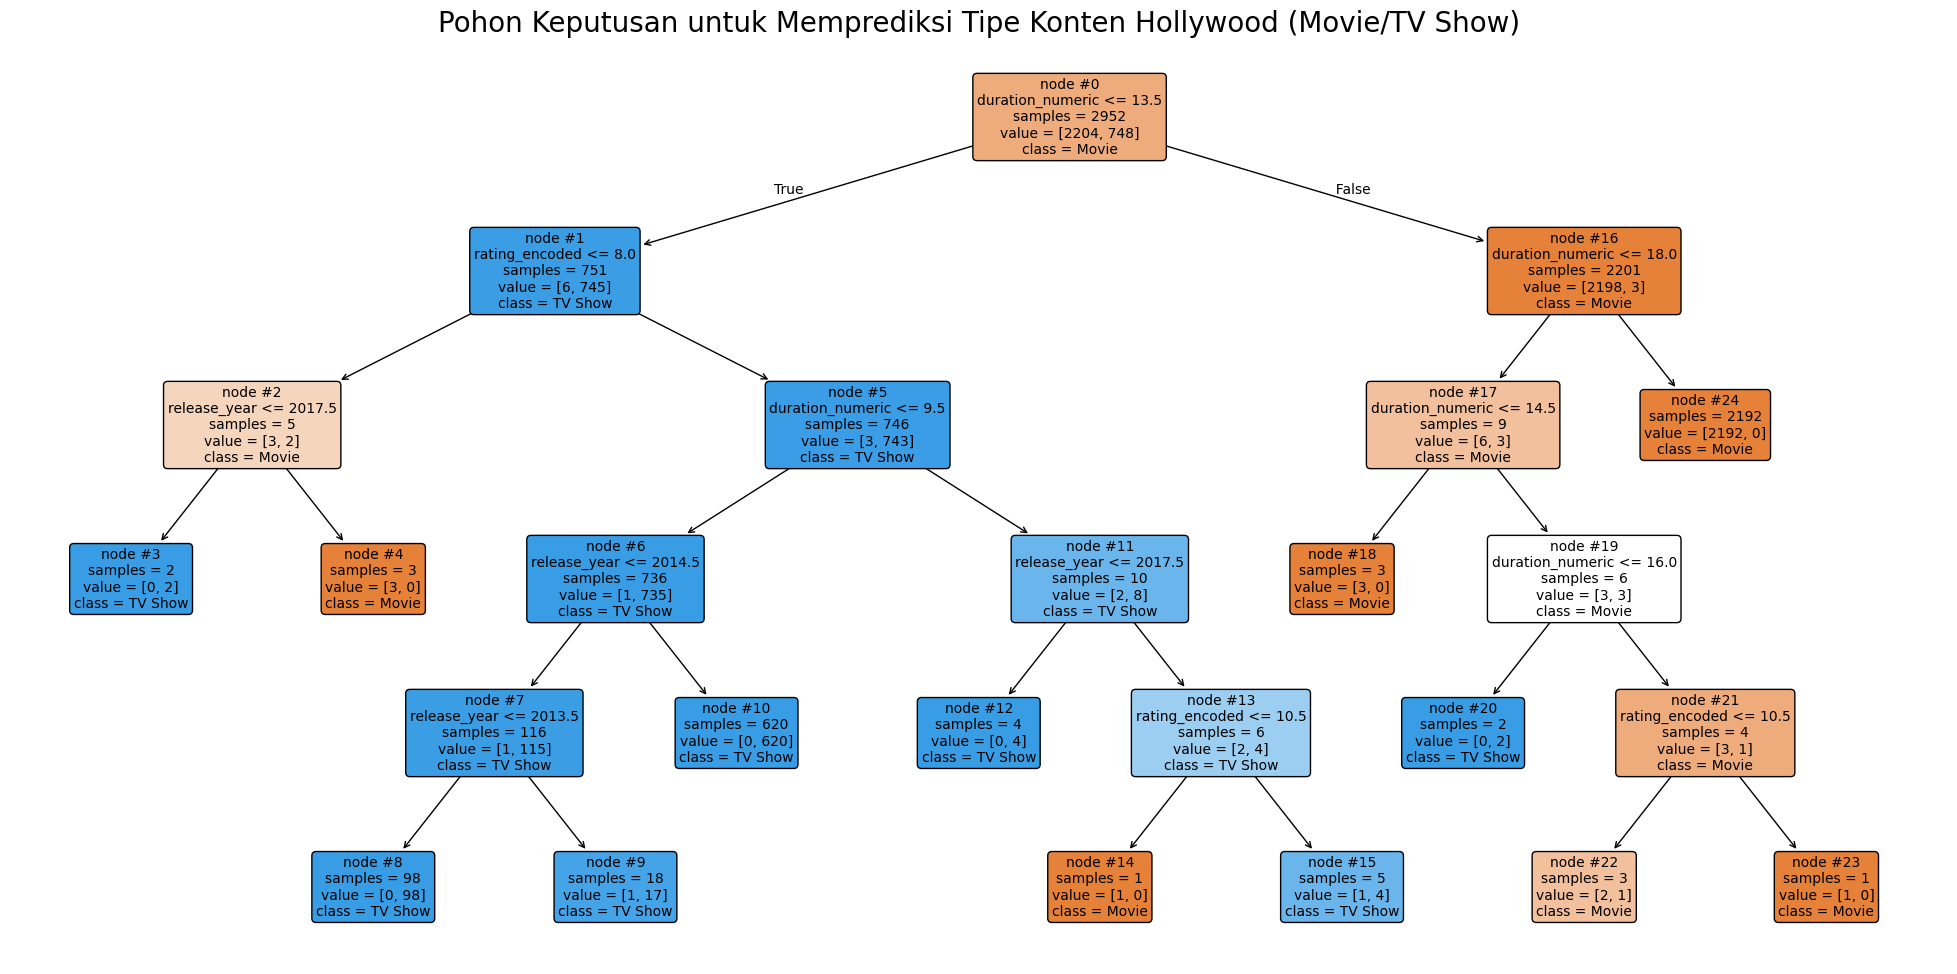


--- Visualisasi Pentingnya Fitur (Feature Importance) ---


/tmp/ipython-input-23-1747724845.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


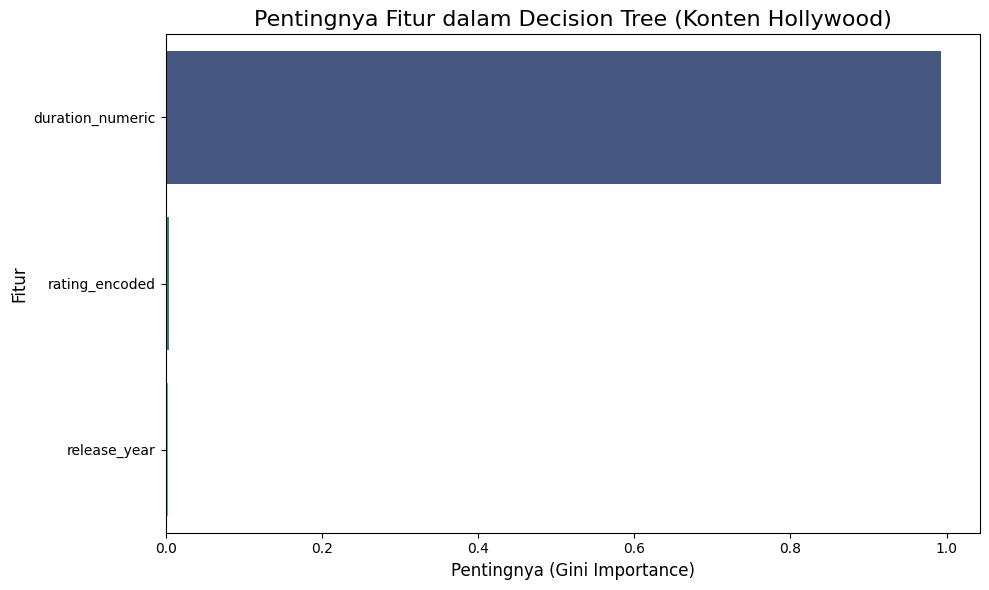


--- Visualisasi Distribusi Fitur Berdasarkan Tipe Konten ---


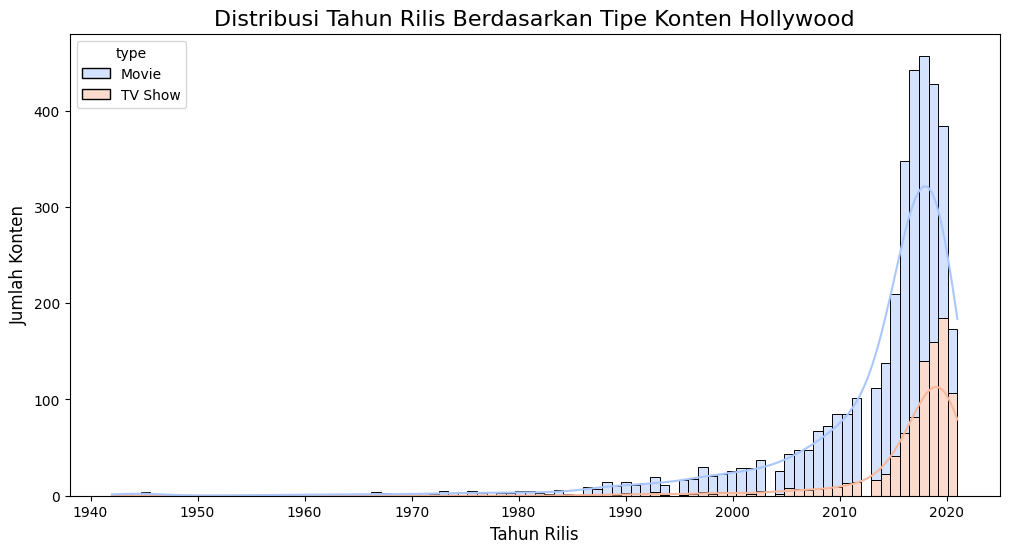

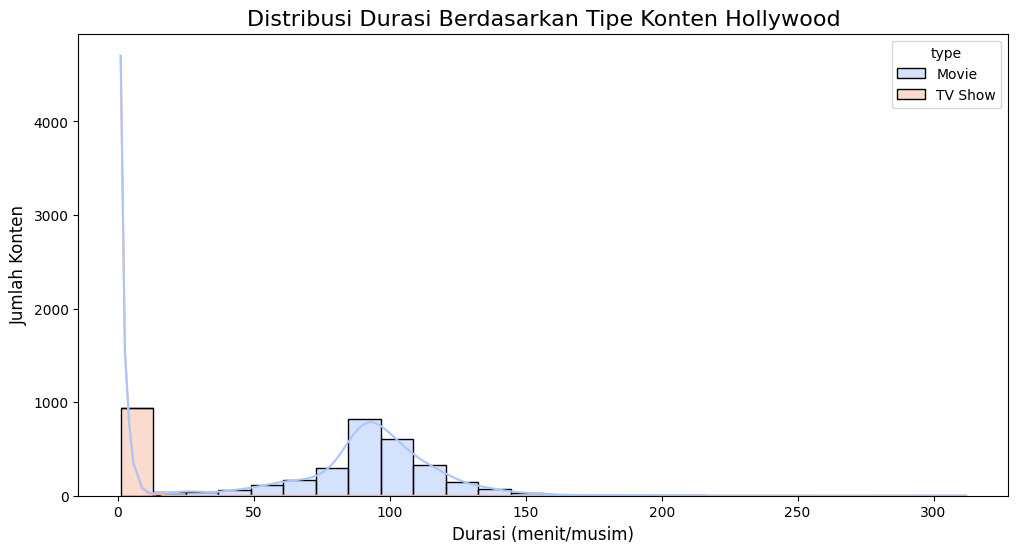

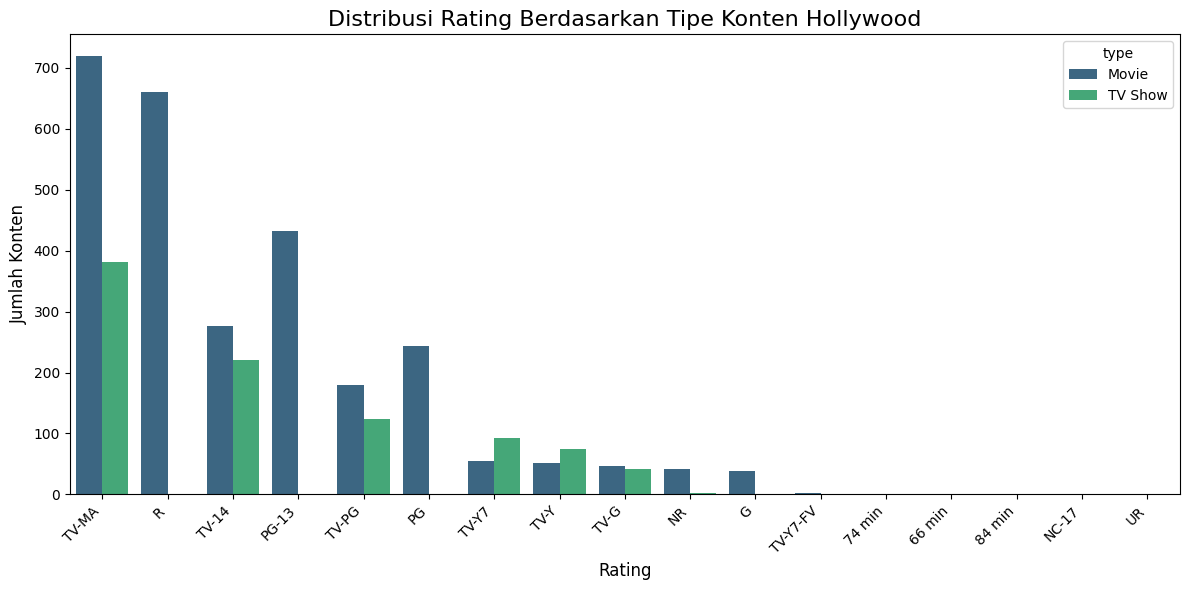


--- Visualisasi Tambahan Selesai ---


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree # Hanya plot_tree yang dibutuhkan di sini
import pandas as pd # Tambahkan impor pandas untuk olah data

# Asumsi: model_dt, features_for_model, le_type sudah didefinisikan
# oleh Bagian 1 (Prediksi Konten Hollywood Tahun 2026) yang dijalankan sebelumnya.
# Juga, hollywood_content_df_cleaned yang berisi data bersih dan le_rating
# diperlukan untuk visualisasi distribusi fitur.

# --- Dummy data for standalone execution (REMOVE THIS BLOCK WHEN INTEGRATED) ---
# This block is only for demonstration purposes if you want to run ONLY this visualization part.
# In a real scenario, these variables would come from your prediction script.
try:
    if 'model_dt' not in locals() or 'features_for_model' not in locals() or 'le_type' not in locals() or 'hollywood_content_df_cleaned' not in locals() or 'le_rating' not in locals():
        print("Peringatan: Variabel-variabel penting tidak ditemukan. Mencoba memuat ulang data dan melatih model untuk visualisasi.")

        # Simulate loading and preprocessing
        df = pd.read_csv("Netflix Datasets Evaluation MS Excel.csv")
        df_filtered_for_hollywood = df.dropna(subset=['country']).copy()
        df_filtered_for_hollywood['country'] = df_filtered_for_hollywood['country'].astype(str)
        hollywood_df = df_filtered_for_hollywood[df_filtered_for_hollywood['country'].str.contains('United States', case=False, na=False)]

        hollywood_df['duration_numeric'] = hollywood_df['duration'].str.extract('(\d+)').astype(float)
        hollywood_df['duration_numeric'] = hollywood_df['duration_numeric'].fillna(hollywood_df['duration_numeric'].median())

        features = ['release_year', 'rating', 'duration_numeric']
        target = 'type'
        hollywood_content_df_cleaned = hollywood_df[features + [target]].dropna()

        from sklearn.preprocessing import LabelEncoder
        le_rating = LabelEncoder()
        hollywood_content_df_cleaned['rating_encoded'] = le_rating.fit_transform(hollywood_content_df_cleaned['rating'])
        features_for_model = ['release_year', 'rating_encoded', 'duration_numeric']

        X = hollywood_content_df_cleaned[features_for_model]
        y = hollywood_content_df_cleaned[target]
        le_type = LabelEncoder()
        y_encoded = le_type.fit_transform(y)

        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

        from sklearn.tree import DecisionTreeClassifier
        model_dt = DecisionTreeClassifier(random_state=42, max_depth=5)
        model_dt.fit(X_train, y_train)

except FileNotFoundError:
    print("ERROR: File 'Netflix Datasets Evaluation MS Excel.csv' tidak ditemukan. Tidak dapat menjalankan visualisasi tanpa data.")
    exit()
# --- END of Dummy data for standalone execution ---


if 'model_dt' in locals() and 'features_for_model' in locals() and 'le_type' in locals() and 'hollywood_content_df_cleaned' in locals():
    print("\n--- Memulai Visualisasi Algoritma Decision Tree dan Analisis Data ---")

    # --- Visualisasi Pohon Keputusan (Decision Tree Plot) ---
    print("\n--- Visualisasi Pohon Keputusan (Decision Tree Plot) ---")

    plt.figure(figsize=(25, 12))
    plot_tree(model_dt,
              feature_names=features_for_model,
              class_names=le_type.classes_,
              filled=True,
              rounded=True,
              fontsize=10,
              impurity=False,
              node_ids=True,
              proportion=False
             )
    plt.title('Pohon Keputusan untuk Memprediksi Tipe Konten Hollywood (Movie/TV Show)', fontsize=20)
    plt.show()

    # --- Visualisasi Pentingnya Fitur (Feature Importance) ---
    print("\n--- Visualisasi Pentingnya Fitur (Feature Importance) ---")
    importance_df = pd.DataFrame({
        'Feature': features_for_model,
        'Importance': model_dt.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
    plt.title('Pentingnya Fitur dalam Decision Tree (Konten Hollywood)', fontsize=16)
    plt.xlabel('Pentingnya (Gini Importance)', fontsize=12)
    plt.ylabel('Fitur', fontsize=12)
    plt.tight_layout()
    plt.show()

    # --- Visualisasi Tambahan: Distribusi Fitur Berdasarkan Tipe Konten ---
    print("\n--- Visualisasi Distribusi Fitur Berdasarkan Tipe Konten ---")

    # Distribusi Release Year
    plt.figure(figsize=(12, 6))
    sns.histplot(data=hollywood_content_df_cleaned, x='release_year', hue='type', multiple='stack', kde=True, palette='coolwarm')
    plt.title('Distribusi Tahun Rilis Berdasarkan Tipe Konten Hollywood', fontsize=16)
    plt.xlabel('Tahun Rilis', fontsize=12)
    plt.ylabel('Jumlah Konten', fontsize=12)
    plt.show()

    # Distribusi Duration Numeric
    plt.figure(figsize=(12, 6))
    sns.histplot(data=hollywood_content_df_cleaned, x='duration_numeric', hue='type', multiple='stack', kde=True, palette='coolwarm')
    plt.title('Distribusi Durasi Berdasarkan Tipe Konten Hollywood', fontsize=16)
    plt.xlabel('Durasi (menit/musim)', fontsize=12)
    plt.ylabel('Jumlah Konten', fontsize=12)
    plt.show()

    # Distribusi Rating (Categorical - Countplot)
    plt.figure(figsize=(12, 6))
    sns.countplot(data=hollywood_content_df_cleaned, x='rating', hue='type', palette='viridis', order=hollywood_content_df_cleaned['rating'].value_counts().index)
    plt.title('Distribusi Rating Berdasarkan Tipe Konten Hollywood', fontsize=16)
    plt.xlabel('Rating', fontsize=12)
    plt.ylabel('Jumlah Konten', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("\n--- Visualisasi Tambahan Selesai ---")

else:
    print("Peringatan: Variabel-variabel penting (model_dt, features_for_model, le_type, hollywood_content_df_cleaned) tidak ditemukan.")
    print("Harap jalankan Bagian 1 (Prediksi Konten Hollywood) terlebih dahulu untuk melatih model dan memuat data yang diperlukan.")